In [17]:
from numpy import argmin, meshgrid, append, max, min, array, arcsin, sin, pi, log10
from pandas import read_excel
from phc_codes.spectra_utils import clip_wl
import matplotlib.pyplot as plt
%matplotlib widget

## Load and pick excel multicolum data

In [18]:
data = read_excel(
    r"D:\Somnath_data\LAB\lab_expt_data\Nov17_2025\cu_0\6000rpm\RK\6000rk.xlsx",
    header=None,
)
int_time = float(data.iloc[2, 1])
nr_avg = float(data.iloc[3, 1])
measured_angles = array([float(angle[:-4]) for angle in data.iloc[0, 1:]])
angles = measured_angles # for hemicylindrical prism
spectrum_data = data.iloc[6:, :].to_numpy(float)
# print(data.head(7))

## angle conversion for right angle prism

incident angle on phc $\theta_i$ and measured angle on protactor $\theta_p$ are related by -
$$ \theta_i = 45^o + \sin^{-1}\left(\dfrac{\sin(\theta_p - 45^o)}{n_{prism}}\right)$$

In [19]:
#n_prism = 1.5
#angles = 45.0 + 180.0 * arcsin(sin((measured_angles - 45) * pi / 180)/ n_prism) / pi
#print(angles)

## plot the dispersion data

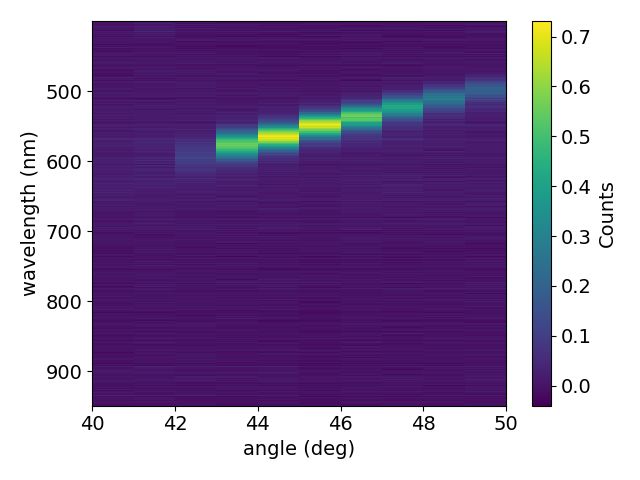

In [20]:
# wavelength range to plot
wl1 = 400
wl2 = 950

spectrum_data = clip_wl(spectrum_data, wl1, wl2)
wavelengths = spectrum_data[:, 0]
reflectance = spectrum_data[:, 1:]
offset_reflectance =  reflectance  #- min(reflectance, axis=0)
normalized_reflectance = offset_reflectance #/ max(offset_reflectance, axis=0)
normalized_reflectance /= int_time # for KR data 

X, Y = meshgrid(append(angles, angles[-1]), append(wavelengths, wavelengths[-1]))
#plot_data = log10(normalized_reflectance+100)
plot_data = normalized_reflectance

plt.figure(1)
plt.clf()
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots()
cplot = ax.pcolormesh(
    X, Y, plot_data, shading="flat", antialiased=True
)  # x_tick = row index, y_tick = column index
#fig.colorbar(cplot, label="Reflectance")#"log$_{10}$(count)")
fig.colorbar(cplot, label="Counts")
#fig.colorbar(cplot, label="Reflectance")
plt.xlabel("angle (deg)")
plt.ylabel("wavelength (nm)")
ax.invert_yaxis()
#plt.plot(data[:,0], data[:,3])
plt.tight_layout()
plt.show()

## Reflection spectrum at specific angles

In [21]:
print(angles)

[40. 41. 42. 43. 44. 45. 46. 47. 48. 49. 50.]


In [ ]:
plot_angles = [44]
plt.figure(2)
plt.clf()

for angle in plot_angles:
    plt.plot(wavelengths, normalized_reflectance[:, argmin(abs(angles-angle))])

plt.legend(plot_angles, title="angle")
plt.xlabel("wavelength (nm)")
plt.ylabel("counts")
plt.show()

## Addtion of TE and TM polarized light to match with unpolarized light data

In [ ]:
## Load the other data
data = read_excel(
    r"D:\lab_expt_data\july04_2025\s9\6000\KR\kr6000.xlsx",
    header=None,
)
measured_angles = array([float(angle[:2]) for angle in data.iloc[0, 1:]])
angles = measured_angles # for hemicylindrical prism
spectrum_data = data.iloc[6:, :].to_numpy(float)
# print(data.head(7))

## sum the two data
# wavelength range to plot
wl1 = 400
wl2 = 950

spectrum_data = clip_wl(spectrum_data, wl1, wl2)
wavelengths = spectrum_data[:, 0]
reflectance = spectrum_data[:, 1:]
offset_reflectance = reflectance  # - min(reflectance, axis=0)
normalized_reflectance2 = offset_reflectance / max(offset_reflectance, axis=0)
added_reflectance = (normalized_reflectance[:, :] + normalized_reflectance2[:, :-1]) / 2

In [ ]:
## plot the data


X, Y = meshgrid(angles, append(wavelengths, wavelengths[-1]))

plt.figure(4)
plt.clf()
fig, ax = plt.subplots()
ax.pcolormesh(
    X, Y, added_reflectance, shading="flat", antialiased=True
)  # x_tick = row index, y_tick = column index
# plt.colorbar(plot_data)
plt.xlabel("angle (deg) -->")
plt.ylabel("wavelength (nm) -->")
ax.invert_yaxis()
# plt.plot(data[:,0], data[:,3])
plt.show()